# Assignemnt2 
## 40 different house electricity consumption
There are two datasets **Main_data** and corresponding **Weather_data** 

### What the datasets represent

A synthetic smart-grid panel time series:
40 buildings (meter_id = M001…M040)

Hourly readings for 500 hours starting 2025-01-01 00:00

Total rows: 40 × 500 = 20,000

-------------------
### Main_data
Each row in **Main_data** file is one meter at one hour, with building attributes + pricing + behavior driving energy consumption.

Column groups (what’s inside)
1) Identifiers & time meter_id, timestamp
hour

2) Building “static” attributes (vary by meter)
building_type (residential/commercial/industrial)
region
floor_area_m2
insulation_rating (scaled from 0 to 1)
hvac_age_years (scaled from 0 to 20.2 years)
solar_kw_installed (scaled from 0 to 6.5 kw)
ev_charger (0/1)

3) grid conditions (vary by hour and region)

grid_price_usd_per_kwh
price depends on tariff tier and “temperature stress.”

4) Behavior & generation
   
occupancy_index (0–1 synthetic activity proxy)
solar_generation_kwh (daytime profile, reduced when precip > 0)

5) targeted variable
consumption_kwh (net kWh after solar)
----------------
### Weather_data
Weather data related to each meter_id is available in **Weather_data.CSV** file
Columns inside 
temp_c, humidity_pct, wind_ms, precip_mm
Weather has a diurnal cycle and region baselines; 
Weathers has a diurnal cycle and region baselines; price depends on tariff tier and “temperature stress.”


---------------------
# Please do the following tasks
1) Read the datasets and check the info, type of data, and so on.
2) Generate calendar features such as hour, day_of_week, is_weekend, and is_holiday? **Tips**:  Check the type of 'timestamp'column.
3) Generate per‑meter lag features such as lag1,lag24 over the consumption column. **Tips**: groupby method matters for each meter_id.
4) Generate per‑meter rolling features such as 24-hour consumption average and std.
5) Generate one main dataset with the index of timeseries data and concatenated with the corresponding weather dataset.
   
   --------------------
**From now on, it is very subjective and depends on the usecase you choose. It is up to you to test and check your learning by answering the following questions with different tools and tests.**

6) Choose one arbitrary meter_id related to residential building type and start presenting descriptive statistics over interesting columns such as consumption, weather data, and so on.
7) Please use different plot types visualization tools in seaborn or other Python packages to present more statistical information related to the selected meter_id over targeted column energy consumption or other interesting predictors such as weather data, solar generation, and so on.
8) Study the relation of the user_behavior information, such as weekend, is_holiday, with respect to the targeted variable, energy consumption.
9) How did your targeted variable respond to different energy prices and Tarif_tier?
10) Check that your data are stationary. Is there seasonality or a periodic component in your data? **Tips:** You can just do these analyses over the targeted variable. 
11)  Decompose the main component if there are periodic and nonstationary.
12)  Stationerise your data if it is needed.
----------------------------------------------------------
If you have time, choose another meter_id related to a commercial building and do the tasks from 6 to 10, and compare your findings with the residential one. 

### Task 1: Read the datasets and check the info, type of data, and so on.

In this step we load the two CSV files, parse the timestamp column, and check shape, sample rows, data types, and full dataframe info.


In [30]:
from pathlib import Path
import pandas as pd

base_dir = Path('.')
main_path = base_dir / 'Main_data.csv'
weather_path = base_dir / 'Weather_data.CSV'

main_df = pd.read_csv(main_path, parse_dates=['timestamp'])
weather_df = pd.read_csv(weather_path, parse_dates=['timestamp'])

print(f'Main data shape: {main_df.shape}')
print(f'Weather data shape: {weather_df.shape}')
display(main_df.head(3))
display(weather_df.head(3))

print('\nMain data dtypes:')
display(main_df.dtypes.to_frame('dtype'))
print('\nWeather data dtypes:')
display(weather_df.dtypes.to_frame('dtype'))

print('\nMain data info:')
main_df.info()
print('\nWeather data info:')
weather_df.info()


Main data shape: (20000, 14)
Weather data shape: (20000, 6)


,meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,tariff_tier,grid_price_usd_per_kwh,occupancy_index,solar_generation_kwh,consumption_kwh
0,M001,2025-01-01 00:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1330,0.145,0.0,2.7074
1,M001,2025-01-01 01:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1200,0.180,0.0,2.5389
2,M001,2025-01-01 02:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1308,0.239,0.0,2.6194


,timestamp,meter_id,temp_c,humidity_pct,wind_ms,precip_mm
0,2025-01-01 00:00:00,M001,0.41,44.0,2.73,0.0
1,2025-01-01 01:00:00,M001,1.34,53.5,3.18,0.0
2,2025-01-01 02:00:00,M001,1.22,55.9,4.64,0.0



Main data dtypes:


,dtype
meter_id,str
timestamp,datetime64[us]
region,str
building_type,str
floor_area_m2,int64
insulation_rating,float64
hvac_age_years,float64
solar_kw_installed,float64
ev_charger,int64
tariff_tier,str



Weather data dtypes:


,dtype
timestamp,datetime64[us]
meter_id,str
temp_c,float64
humidity_pct,float64
wind_ms,float64
precip_mm,float64



Main data info:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   meter_id                20000 non-null  str           
 1   timestamp               20000 non-null  datetime64[us]
 2   region                  20000 non-null  str           
 3   building_type           20000 non-null  str           
 4   floor_area_m2           20000 non-null  int64         
 5   insulation_rating       20000 non-null  float64       
 6   hvac_age_years          20000 non-null  float64       
 7   solar_kw_installed      20000 non-null  float64       
 8   ev_charger              20000 non-null  int64         
 9   tariff_tier             20000 non-null  str           
 10  grid_price_usd_per_kwh  20000 non-null  float64       
 11  occupancy_index         20000 non-null  float64       
 12  solar_generation_kwh    20000 non-null  

### Task 2: Generate calendar features such as hour, day_of_week, is_weekend, and is_holiday? Tips: Check the type of 'timestamp' column.

Here we derive time-based features from `timestamp`: hour, day of week, weekend flag, and a holiday flag.


In [31]:
from pandas.tseries.holiday import USFederalHolidayCalendar

main_df['hour'] = main_df['timestamp'].dt.hour
main_df['day_of_week'] = main_df['timestamp'].dt.dayofweek
main_df['is_weekend'] = (main_df['day_of_week'] >= 5).astype(int)

cal = USFederalHolidayCalendar()
holidays = cal.holidays(
    start=main_df['timestamp'].min().normalize(),
    end=main_df['timestamp'].max().normalize()
)
main_df['is_holiday'] = main_df['timestamp'].dt.normalize().isin(holidays).astype(int)

display(main_df[['timestamp', 'hour', 'day_of_week', 'is_weekend', 'is_holiday']].head(10))


,timestamp,hour,day_of_week,is_weekend,is_holiday
0,2025-01-01 00:00:00,0,2,0,1
1,2025-01-01 01:00:00,1,2,0,1
2,2025-01-01 02:00:00,2,2,0,1
3,2025-01-01 03:00:00,3,2,0,1
4,2025-01-01 04:00:00,4,2,0,1
5,2025-01-01 05:00:00,5,2,0,1
6,2025-01-01 06:00:00,6,2,0,1
7,2025-01-01 07:00:00,7,2,0,1
8,2025-01-01 08:00:00,8,2,0,1
9,2025-01-01 09:00:00,9,2,0,1


### Task 3: Generate per-meter lag features such as lag1, lag24 over the consumption column. Tips: groupby method matters for each meter_id.

We sort by meter and time, then create lag values of consumption (`lag1` and `lag24`) within each `meter_id` group.


In [32]:
required_cols = {'meter_id', 'consumption_kwh'}
missing = required_cols - set(main_df.columns)

main_df = main_df.sort_values(['meter_id', 'timestamp']).copy()
grp = main_df.groupby('meter_id', sort=False)['consumption_kwh']
main_df['lag1'] = grp.shift(1)
main_df['lag24'] = grp.shift(24)

display(main_df[['meter_id', 'timestamp', 'consumption_kwh', 'lag1', 'lag24']].head(30))


,meter_id,timestamp,consumption_kwh,lag1,lag24
0,M001,2025-01-01 00:00:00,2.7074,NaN,NaN
1,M001,2025-01-01 01:00:00,2.5389,2.7074,NaN
2,M001,2025-01-01 02:00:00,2.6194,2.5389,NaN
3,M001,2025-01-01 03:00:00,2.3420,2.6194,NaN
4,M001,2025-01-01 04:00:00,2.6295,2.3420,NaN
5,M001,2025-01-01 05:00:00,2.2090,2.6295,NaN
6,M001,2025-01-01 06:00:00,1.6002,2.2090,NaN
7,M001,2025-01-01 07:00:00,1.5037,1.6002,NaN
8,M001,2025-01-01 08:00:00,0.7454,1.5037,NaN
9,M001,2025-01-01 09:00:00,0.1676,0.7454,NaN


### Task 4: Generate per-meter rolling features such as 24-hour consumption average and std.

In this step we calculate 24-hour rolling mean and standard deviation of consumption for each meter separately.


In [33]:
main_df['rolling24_mean'] = grp.transform(lambda s: s.rolling(window=24, min_periods=1).mean())
main_df['rolling24_std'] = grp.transform(lambda s: s.rolling(window=24, min_periods=1).std())

display(main_df[['meter_id', 'timestamp', 'consumption_kwh', 'rolling24_mean', 'rolling24_std']].head(30))


,meter_id,timestamp,consumption_kwh,rolling24_mean,rolling24_std
0,M001,2025-01-01 00:00:00,2.7074,2.707400,NaN
1,M001,2025-01-01 01:00:00,2.5389,2.623150,0.119147
2,M001,2025-01-01 02:00:00,2.6194,2.621900,0.084278
3,M001,2025-01-01 03:00:00,2.3420,2.551925,0.155952
4,M001,2025-01-01 04:00:00,2.6295,2.567440,0.139443
5,M001,2025-01-01 05:00:00,2.2090,2.507700,0.192273
6,M001,2025-01-01 06:00:00,1.6002,2.378057,0.385303
7,M001,2025-01-01 07:00:00,1.5037,2.268763,0.472030
8,M001,2025-01-01 08:00:00,0.7454,2.099500,0.672911
9,M001,2025-01-01 09:00:00,0.1676,1.906310,0.880750


### Task 5: Generate one main dataset with the index of timeseries data and concatenated with the corresponding weather dataset.

Finally, we join main data with weather data on `meter_id` and `timestamp`, set `timestamp` as index, and save the result.


In [34]:
final_df = main_df.merge(weather_df, on=['meter_id', 'timestamp'], how='left', suffixes=('', '_weather'))

final_df = final_df.sort_values(['meter_id', 'timestamp']).set_index('timestamp')

print('Final dataset shape:', final_df.shape)
print('Rows preserved after merge:', len(final_df) == len(main_df))
display(final_df.head(10))

output_path = base_dir / 'main_with_weather_features.csv'
final_df.to_csv(output_path)
print(f'Engineered dataset saved to: {output_path.resolve()}')


Final dataset shape: (20000, 25)
Rows preserved after merge: True


,meter_id,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,tariff_tier,grid_price_usd_per_kwh,...,is_weekend,is_holiday,lag1,lag24,rolling24_mean,rolling24_std,temp_c,humidity_pct,wind_ms,precip_mm
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1330,...,0,1,NaN,NaN,2.707400,NaN,0.41,44.0,2.73,0.0
2025-01-01 01:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1200,...,0,1,2.7074,NaN,2.623150,0.119147,1.34,53.5,3.18,0.0
2025-01-01 02:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1308,...,0,1,2.5389,NaN,2.621900,0.084278,1.22,55.9,4.64,0.0
2025-01-01 03:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1216,...,0,1,2.6194,NaN,2.551925,0.155952,3.03,61.0,3.02,0.5
2025-01-01 04:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1323,...,0,1,2.3420,NaN,2.567440,0.139443,1.36,65.8,4.45,0.0
2025-01-01 05:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1362,...,0,1,2.6295,NaN,2.507700,0.192273,2.76,57.2,4.74,0.0
2025-01-01 06:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,off_peak,0.1139,...,0,1,2.2090,NaN,2.378057,0.385303,9.19,66.1,1.80,0.0
2025-01-01 07:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,mid_peak,0.1693,...,0,1,1.6002,NaN,2.268763,0.472030,5.10,67.6,1.05,3.0
2025-01-01 08:00:00,M001,W,commercial,113,0.709966,16.486924,2.762723,1,mid_peak,0.1629,...,0,1,1.5037,NaN,2.099500,0.672911,6.35,69.4,2.98,0.0


Engineered dataset saved to: /Users/orjan/Code/hvl/delivery01/dat803/oppgave-02/main_with_weather_features.csv


### Task 6: Choose one arbitrary meter_id related to residential building type and start presenting descriptive statistics over interesting columns such as consumption, weather data, and so on.

We filter residential meter `M010` and show short descriptive statistics for consumption and weather features.


In [35]:
selected_meter = 'M010'
meter_df = final_df[final_df['meter_id'] == selected_meter].copy()

print(f'Selected meter: {selected_meter}')
print(f'Rows: {len(meter_df)}')
print(f'Building type: {meter_df["building_type"].iloc[0]}')

stats_cols = [
    'consumption_kwh', 'solar_generation_kwh', 'grid_price_usd_per_kwh',
    'temp_c', 'humidity_pct', 'wind_ms', 'precip_mm'
]
display(meter_df[stats_cols].describe().T.round(3))


Selected meter: M010
Rows: 500
Building type: residential


,count,mean,std,min,25%,50%,75%,max
consumption_kwh,500.0,1.007,0.560,0.000,0.594,1.022,1.398,4.975
solar_generation_kwh,500.0,0.173,0.211,0.000,0.000,0.000,0.393,0.619
grid_price_usd_per_kwh,500.0,0.167,0.041,0.109,0.132,0.155,0.214,0.252
temp_c,500.0,5.912,3.078,-1.800,3.330,6.185,8.490,14.360
humidity_pct,500.0,49.939,9.335,27.500,42.750,50.100,56.925,74.400
wind_ms,500.0,3.129,2.173,0.060,1.568,2.665,4.132,12.810
precip_mm,500.0,0.254,0.909,0.000,0.000,0.000,0.000,6.000


### Task 7: Please use different plot types visualization tools in seaborn or other Python packages to present more statistical information related to the selected meter_id over targeted column energy consumption or other interesting predictors such as weather data, solar generation, and so on.

We use a few simple plot types to view consumption, distribution, and weather relation.


/var/folders/xb/kr7h9b9n3h31072fp4swsrpm0000gn/T/ipykernel_32331/4064203394.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()


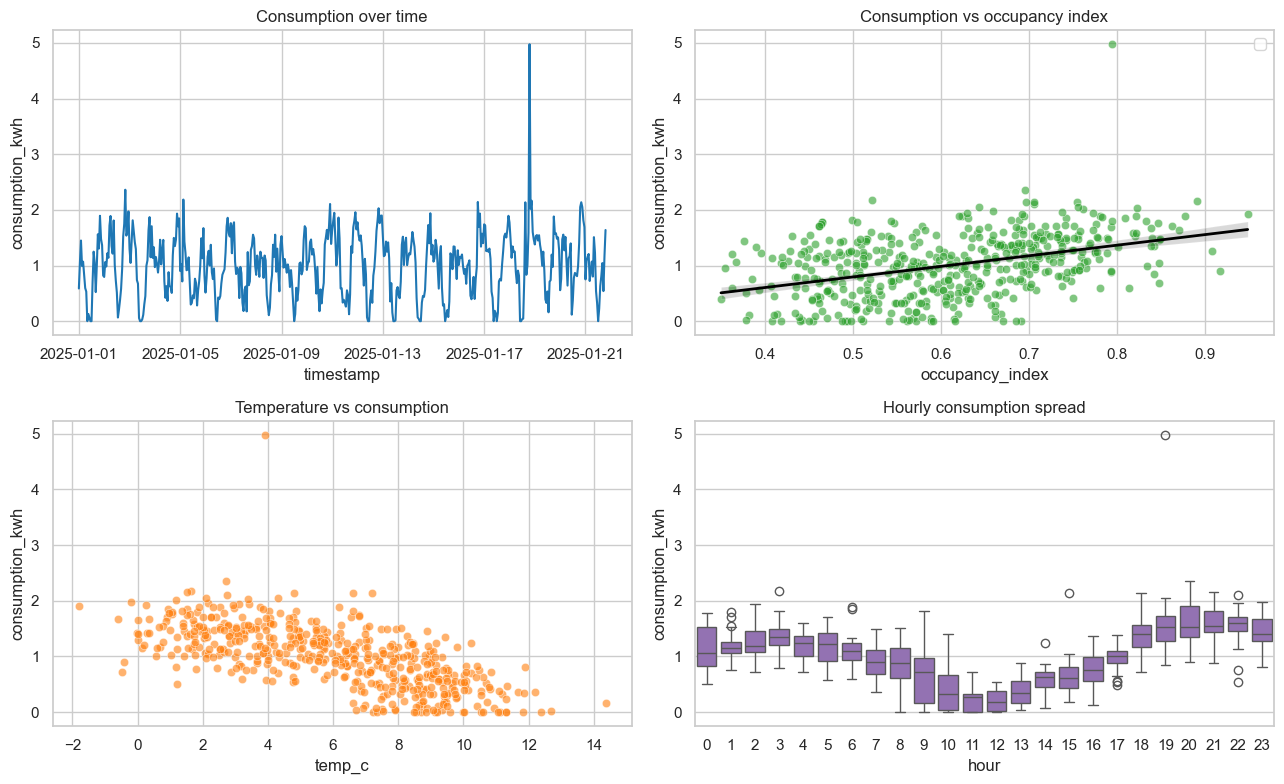

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.lineplot(data=meter_df, x=meter_df.index, y='consumption_kwh', ax=axes[0, 0], color='tab:blue')
axes[0, 0].set_title('Consumption over time')
axes[0, 0].set_xlabel('timestamp')

sns.scatterplot(
    data=meter_df,
    x='occupancy_index',
    y='consumption_kwh',
    ax=axes[0, 1],
    alpha=0.6,
    color='tab:green'
)
sns.regplot(
    data=meter_df,
    x='occupancy_index',
    y='consumption_kwh',
    ax=axes[0, 1],
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)
axes[0, 1].set_title('Consumption vs occupancy index')
axes[0, 1].legend(
    handles=[Line2D([0], [0], color='black', linewidth=2, label='Trend line')]
)

sns.scatterplot(data=meter_df, x='temp_c', y='consumption_kwh', ax=axes[1, 0], alpha=0.6, color='tab:orange')
axes[1, 0].set_title('Temperature vs consumption')

sns.boxplot(data=meter_df, x='hour', y='consumption_kwh', ax=axes[1, 1], color='tab:purple')
axes[1, 1].set_title('Hourly consumption spread')

plt.tight_layout()
plt.show()

### Task 8: Study the relation of the user_behavior information, such as weekend, is_holiday, with respect to the targeted variable, energy consumption.

We compare consumption by `is_weekend` and `is_holiday` flags for meter `M010`.


mean  median    std  count
is_weekend is_holiday                             
0          0           0.963   1.009  0.512    308
           1           1.015   1.024  0.564     48
1          0           1.100   1.102  0.642    144

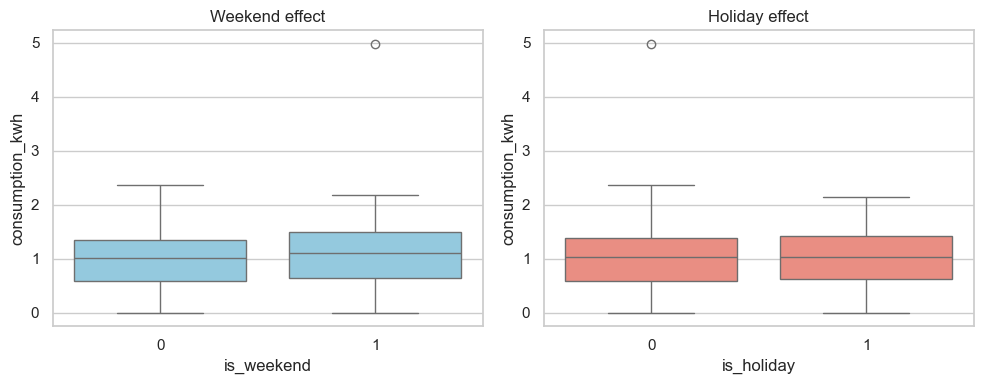

In [37]:
behavior_stats = (
    meter_df.groupby(['is_weekend', 'is_holiday'])['consumption_kwh']
    .agg(['mean', 'median', 'std', 'count'])
    .round(3)
)
display(behavior_stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=meter_df, x='is_weekend', y='consumption_kwh', ax=axes[0], color='skyblue')
axes[0].set_title('Weekend effect')

sns.boxplot(data=meter_df, x='is_holiday', y='consumption_kwh', ax=axes[1], color='salmon')
axes[1].set_title('Holiday effect')

plt.tight_layout()
plt.show()


### Task 9: How did your targeted variable respond to different energy prices and Tarif_tier?

We check correlation with price and compare consumption across tariff tiers.


Correlation(consumption, price): 0.313


,mean,median,std,count
tariff_tier,,,,
on_peak,1.352,1.372,0.522,164
off_peak,1.216,1.196,0.314,147
mid_peak,0.546,0.495,0.407,189


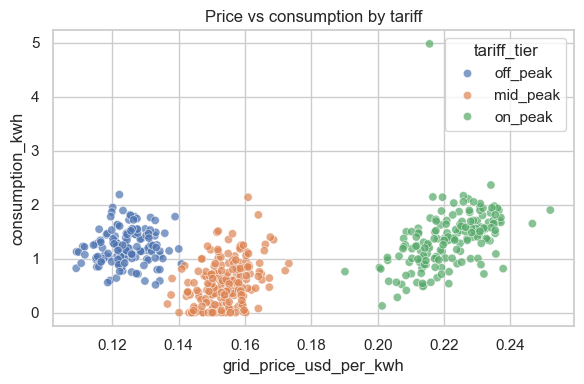

In [38]:
price_corr = meter_df['consumption_kwh'].corr(meter_df['grid_price_usd_per_kwh'])
print(f'Correlation(consumption, price): {price_corr:.3f}')

tariff_stats = (
    meter_df.groupby('tariff_tier')['consumption_kwh']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .round(3)
)
display(tariff_stats)

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=meter_df,
    x='grid_price_usd_per_kwh',
    y='consumption_kwh',
    hue='tariff_tier',
    alpha=0.7
)
plt.title('Price vs consumption by tariff')
plt.tight_layout()
plt.show()


### Task 10: Check that your data are stationary. Is there seasonality or a periodic component in your data? Tips: You can just do these analyses over the targeted variable.

We run an ADF test and inspect autocorrelation to detect non-stationarity and periodic behavior.


ADF statistic: -6.5062
ADF p-value: 0.0000
Critical values: {'1%': np.float64(-3.444), '5%': np.float64(-2.8676), '10%': np.float64(-2.57)}
Interpretation: p < 0.05 means likely stationary.


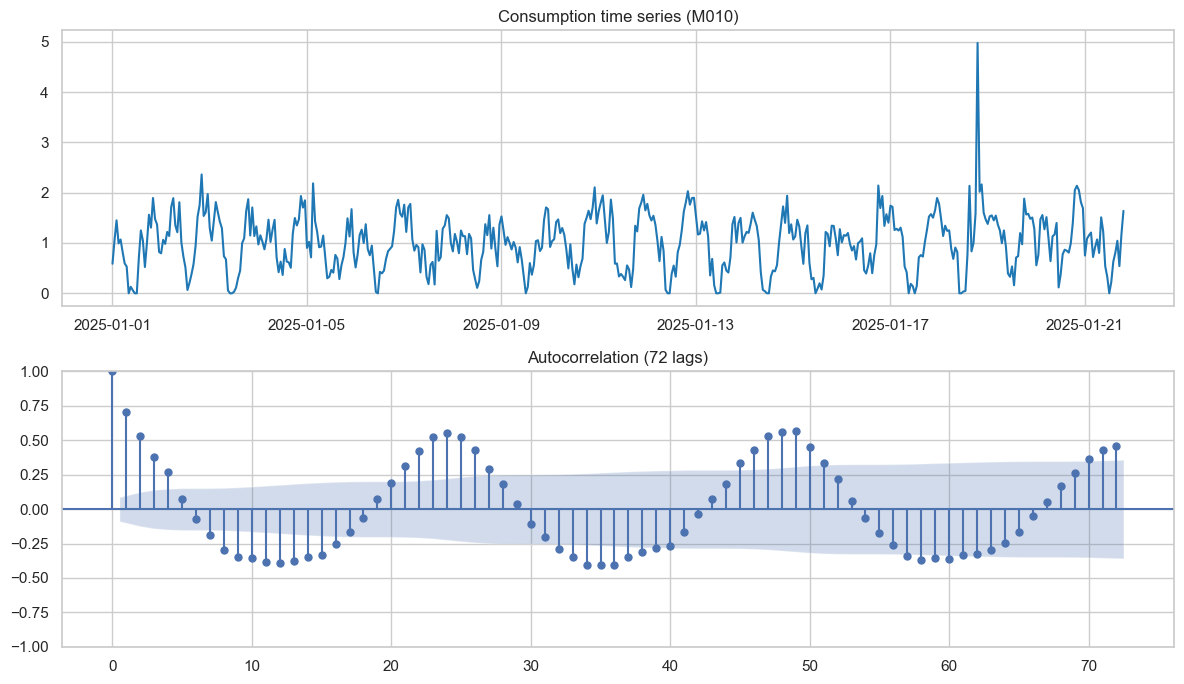

In [39]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

series = meter_df['consumption_kwh'].dropna()
adf_stat, adf_p, _, _, crit_vals, _ = adfuller(series, autolag='AIC')

print(f'ADF statistic: {adf_stat:.4f}')
print(f'ADF p-value: {adf_p:.4f}')
print('Critical values:', {k: round(v, 4) for k, v in crit_vals.items()})
print('Interpretation: p < 0.05 means likely stationary.')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(series.index, series.values, color='tab:blue')
axes[0].set_title('Consumption time series (M010)')

plot_acf(series, lags=72, ax=axes[1])
axes[1].set_title('Autocorrelation (72 lags)')

plt.tight_layout()
plt.show()


### Task 11: Decompose the main component if there are periodic and nonstationary.

We decompose the consumption series with period 24 to separate trend, seasonality, and residual parts.


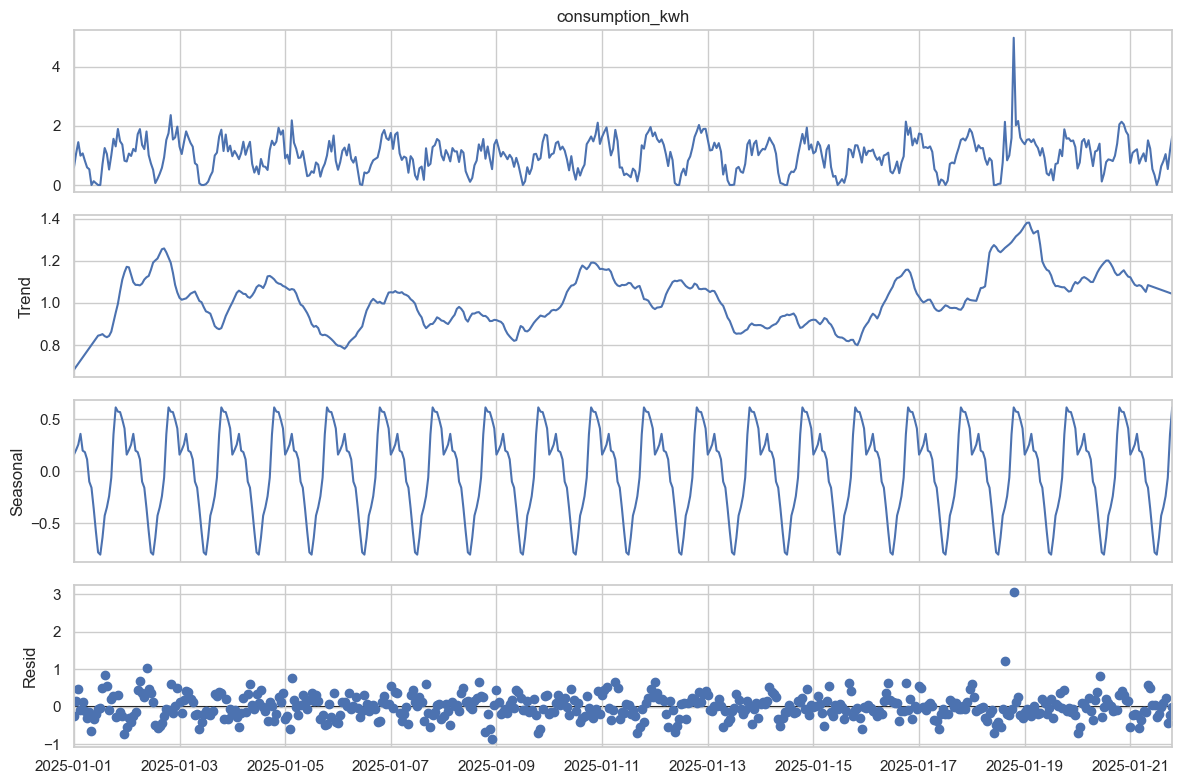

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(series, model='additive', period=24, extrapolate_trend='freq')
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


### Task 12: Stationerise your data if it is needed.

We apply first differencing to `consumption_kwh` and test stationarity again with ADF.


Differenced ADF statistic: -11.6102
Differenced ADF p-value: 0.0000
Critical values: {'1%': np.float64(-3.444), '5%': np.float64(-2.8676), '10%': np.float64(-2.57)}


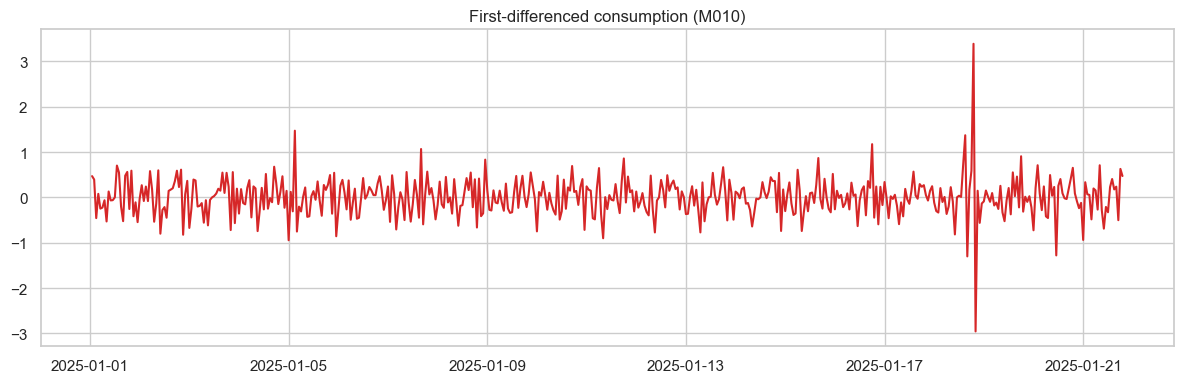

In [41]:
meter_df['consumption_diff1'] = meter_df['consumption_kwh'].diff()
diff_series = meter_df['consumption_diff1'].dropna()

adf_stat_d, adf_p_d, _, _, crit_vals_d, _ = adfuller(diff_series, autolag='AIC')
print(f'Differenced ADF statistic: {adf_stat_d:.4f}')
print(f'Differenced ADF p-value: {adf_p_d:.4f}')
print('Critical values:', {k: round(v, 4) for k, v in crit_vals_d.items()})

plt.figure(figsize=(12, 4))
plt.plot(diff_series.index, diff_series.values, color='tab:red')
plt.title('First-differenced consumption (M010)')
plt.tight_layout()
plt.show()
